In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

In [23]:
c_bar = 1.25
eps = 0.25
p1 = 0.476

def F1(x):
    return lognorm.cdf(x, s=1)

def inv_F1(x):
    return lognorm.ppf(x, s=1)

def F2(x):
    return lognorm.cdf(x, s=1.25)

def inv_F2(x):
    return lognorm.ppf(x, s=1.25)

def compute_costs(t2s, p1):
    def feasible_t1(t2):
        return np.max(c_bar - inv_F1((eps - (1 - p1) * F2(c_bar - t2))/p1))
    
    def cost(t2):
        return p1 * feasible_t1(t2) + (1 - p1) * t2
    
    return np.array([cost(t2) for t2 in t2s])

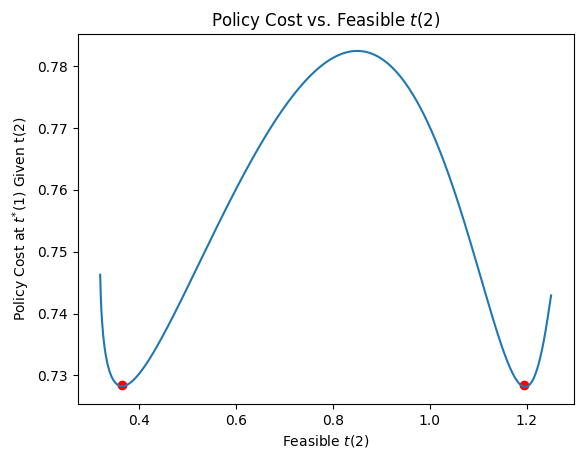

In [49]:
t2s = np.linspace(0., c_bar, 1000)
costs = compute_costs(t2s, p1)
b = ~np.isnan(costs)
plt.plot(t2s[b], costs[b], label="Cost", alpha=1.0)
plt.scatter([0.365, 1.195], [0.7285, 0.7285], color="red", alpha=1.0)
plt.xlabel("Feasible " + r"$t(2)$")
plt.ylabel("Policy Cost at " + r"$t^{*}(1)$" + " Given " + "t(2)") 
plt.title("Policy Cost vs. Feasible " + r"$t(2)$")
plt.savefig("nonunique_cost.pdf")

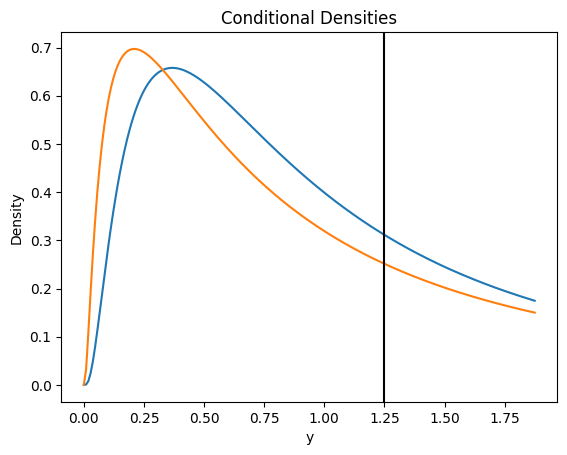

In [56]:
a = np.linspace(0., 1.5 * c_bar, 200)

plt.plot(a, lognorm.pdf(a, s=1), label=r"$f_{Y \mid X=1}$")
plt.plot(a, lognorm.pdf(a, s=1.25), label=r"$f_{Y \mid X=2}")
plt.xlabel("y")
plt.ylabel("Density")
plt.title("Conditional Densities")
plt.axvline(x=c_bar, label=r"$c_bar$", c="black")
plt.savefig("nonunique_cond_density.pdf")
